In [46]:
import MetaTrader5 as mt5
import pandas as pd
import time
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use('dark_background')


Making a master dataframe which contains the OHLCV prices for currency pairs

In [47]:

mt5.initialize()

symbols = ['EURUSD', 'XAUUSD', 'XAGUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD',  'USDCAD', 'AUDCAD', 'NZDCAD', 'AUDCHF', 'CADCHF', 'NZDCHF'  ]
# |----------------------------- DATA EXPLANATION ------------------------------
# | DATA GRANULARITY:
# | 	A smaller timeframe (1 min data) provides more granualar info but also more noise.
# | 	A larger timeframe (1 day data) smooths out short-term fluctuations but might miss intrday opportunities.

# |------------------------------------------------------------------------------|
# |	Impact		   	 | Short Timeframe (1 min)		 | Large Timeframe (1 day)   |
# |------------------|-------------------------------|---------------------------|
# |	Data Granularity | More granualar info but more  | Smooths out short-term	 |
# |				   	 | noise.						 | fluctuations but might	 |
# |				   	 |								 | miss intraday opportunity.|
# |------------------|-------------------------------|---------------------------|
# |	Signal Frequency | Lead to more frequnet signals | Fewer but more significant|
# |				   	 |								 | singals.					 |
# |------------------|-------------------------------|---------------------------|
# |	Execution Speed	 | Require faster execution and	 |							 |
# |				   	 | may incur high transaction	 |							 |
# |				   	 | costs due to more frequent	 |							 |
# |				   	 | trades.						 |						     |
# |------------------|-------------------------------|---------------------------|
# |	Market	 		 | Very small timeframes(seconds |							 |
# |	Microstructure 	 | or minutes) are more affected |							 |
# |				   	 | by market microstructure 	 |							 |
# |				   	 | effects like bid-ask bounce	 |						     |
# |------------------|-------------------------------|---------------------------|

timeframe = mt5.TIMEFRAME_H2
start_date = datetime(2021, 3, 2)
# end_time = datetime(2024, 7, 7)
end_time = datetime.now()
    
def get_data(symbol, timeframe, start_date, end_time):
    rates = mt5.copy_rates_range(symbol, timeframe, start_date, end_time)
    df = pd.DataFrame(rates)
    df = df[['time','close']]
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    return df

def multiple_pairs_data(symbols):
    symbols_data = {}
    for symbol in symbols:
        symbols_data[symbol] = get_data(symbol, timeframe, start_date, end_time)
    # Concatenate data for each symbol into a single DataFrame
    symbols_data_concatenated = pd.concat(symbols_data, axis=1)
    return symbols_data_concatenated


symbols_data_concatenated = multiple_pairs_data(symbols)

symbols_data_concatenated


,EURUSD,XAUUSD,XAGUSD,GBPUSD,AUDUSD,NZDUSD,USDCAD,AUDCAD,NZDCAD,AUDCHF,CADCHF,NZDCHF
,close,close,close,close,close,close,close,close,close,close,close,close
time,,,,,,,,,,,,
2021-03-02 00:00:00,1.20487,1724.96,26.522,1.39286,0.77732,0.72738,1.26409,0.98259,0.91937,0.71118,0.72377,0.66552
2021-03-02 02:00:00,1.20313,1711.74,26.161,1.39059,0.77529,0.72500,1.26665,0.98199,0.91824,0.70998,0.72298,0.66398
2021-03-02 04:00:00,1.20266,1713.42,26.081,1.38916,0.77630,0.72518,1.26722,0.98371,0.91888,0.71057,0.72229,0.66381
2021-03-02 06:00:00,1.20216,1714.78,26.017,1.38815,0.77577,0.72494,1.26834,0.98392,0.91934,0.71050,0.72210,0.66397
2021-03-02 08:00:00,1.20071,1717.82,26.016,1.38787,0.77454,0.72192,1.26922,0.98304,0.91622,0.71011,0.72230,0.66190
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-04 00:00:00,1.10456,2493.08,28.022,1.31112,0.67116,0.61864,1.35452,0.90901,0.83783,0.57053,0.62754,0.52586
2024-09-04 02:00:00,1.10481,2492.38,27.987,1.31038,0.66873,0.61700,1.35544,0.90640,0.83613,0.56729,0.62585,0.52340


Plotting a correlation graph for the close prices of the currency pairs

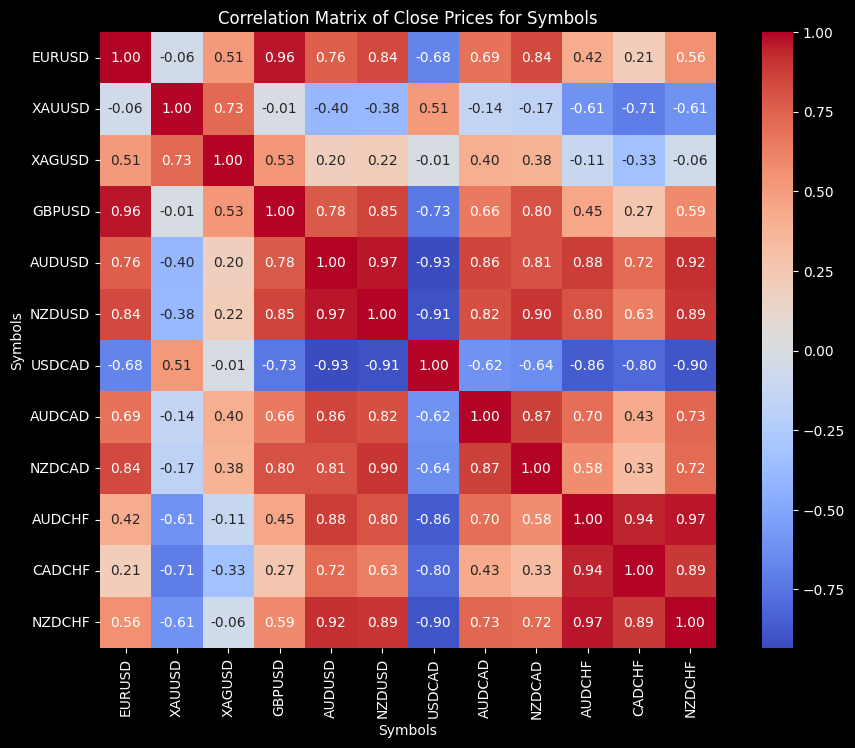

In [48]:
# Extract close prices for each symbol
close_prices = symbols_data_concatenated.xs('close', axis=1, level=1)

# Calculate correlation matrix
correlation_matrix = close_prices.corr()

# Extract close prices for GBPJPY and USDJPY
symbolparam1 = 'XAUUSD'
symbolparam2 = 'XAGUSD'

# Plot correlation matrix as heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix of Close Prices for Symbols')
plt.xlabel('Symbols')
plt.ylabel('Symbols')
plt.show()

Plotting currency pairs so see price movement correlation


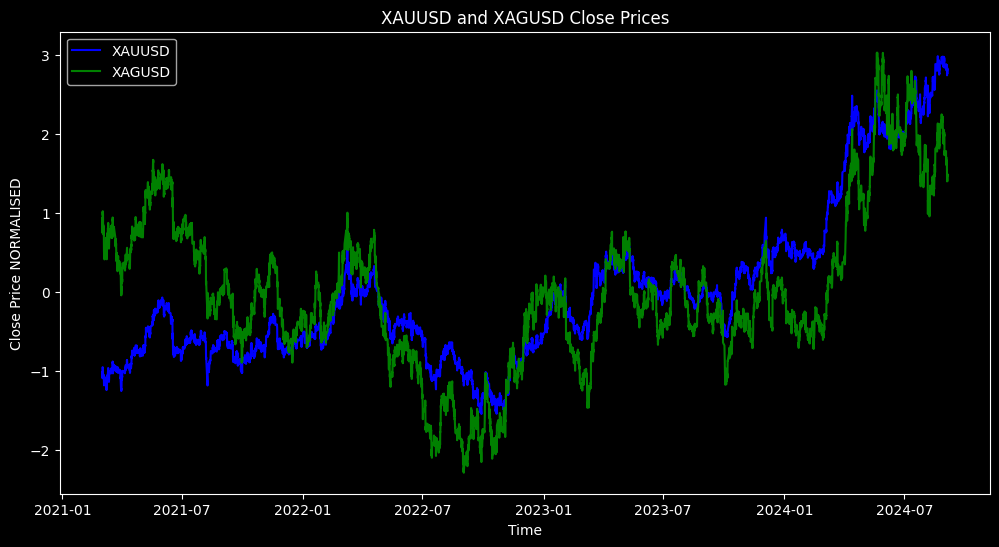

In [49]:
# symbol1 = symbols_data_concatenated['AUDCHF']['close'].dropna()
# symbol2 = symbols_data_concatenated['CADCHF']['close'].dropna()

# symbol1 = symbols_data_concatenated['AUDCHF']['close'].dropna()
# symbol2 = symbols_data_concatenated['CADCHF']['close'].dropna()

symbol1 = symbols_data_concatenated[symbolparam1]['close'].dropna()
symbol2 = symbols_data_concatenated[symbolparam2]['close'].dropna()

# Z-score normalization
normalised1 = (symbol1 - symbol1.mean()) / symbol1.std()
normalised2 = (symbol2 - symbol2.mean()) / symbol2.std()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(normalised1.index, normalised1.values, label=symbolparam1, color='blue')
plt.plot(normalised2.index, normalised2.values, label=symbolparam2, color='green')
plt.title(f'{symbolparam1} and {symbolparam2} Close Prices')
plt.xlabel('Time')
plt.ylabel('Close Price NORMALISED')
plt.legend()
plt.grid(False)
plt.show()

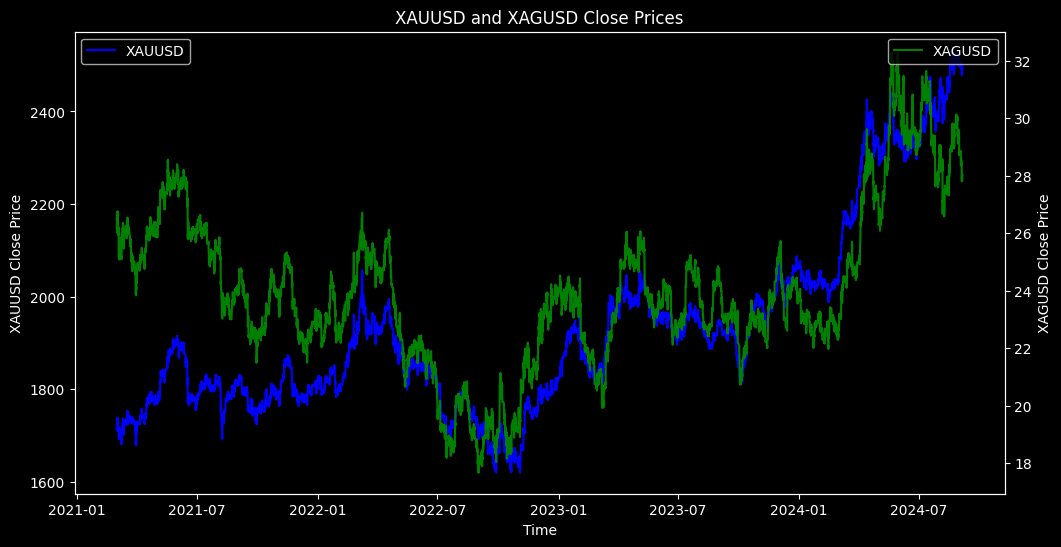

In [50]:

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot GBPJPY on the first axis
ax1.plot(symbol1.index, symbol1.values, label=symbolparam1, color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel(f'{symbolparam1} Close Price')
ax1.tick_params('y')

# Create a twin Axes sharing the same x-axis
ax2 = ax1.twinx()

# Plot USDJPY on the second axis
ax2.plot(symbol2.index, symbol2.values, label=symbolparam2, color='green')
ax2.set_ylabel(f'{symbolparam2} Close Price')
ax2.tick_params('y')

# Add legend
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title(f'{symbolparam1} and {symbolparam2} Close Prices')
plt.grid(False)
plt.show()


Constructing a chart for the difference between the pairs

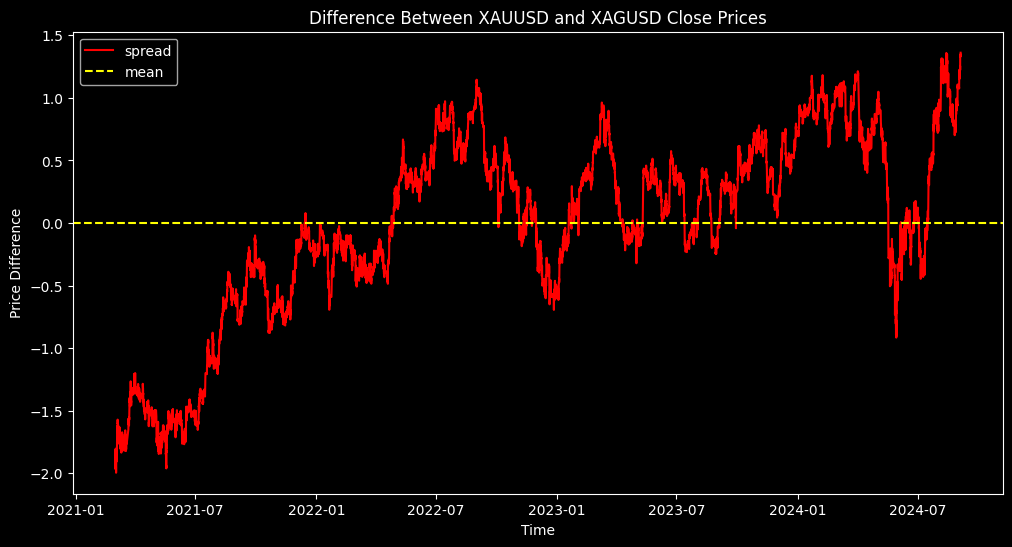

In [51]:
# Calculate the difference between USDJPY and GBPJPY close prices
# NEEDS TO BE NORMALISED
# price_diff = symbol1 - symbol2
price_diff = normalised1 - normalised2

price_diff = price_diff.dropna()

# Plotting the difference
plt.figure(figsize=(12, 6))
plt.plot(price_diff.index, price_diff.values, label='Difference', color='red')
plt.axhline(price_diff.mean(), color = 'yellow', linestyle = '--')
plt.title(f'Difference Between {symbolparam1} and {symbolparam2} Close Prices')
plt.xlabel('Time')
plt.ylabel('Price Difference')
plt.legend(['spread', 'mean'])
plt.grid(False)
plt.show()

In [52]:
# Calculate mean and standard deviation
mu = price_diff.mean()
sigma = price_diff.std()

# Calculate Z-score for each data point
z_scores = (price_diff - mu) / sigma


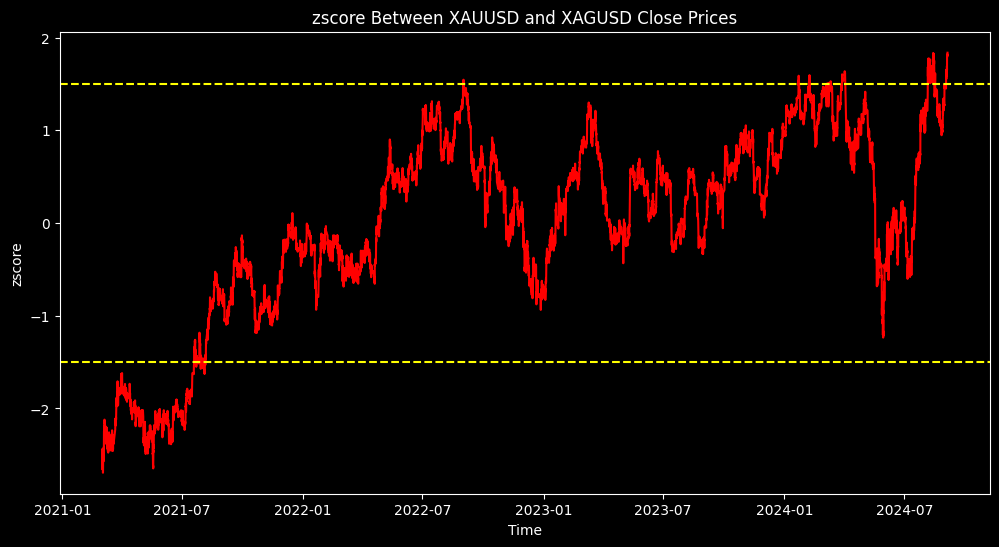

In [53]:
# Plotting the difference
plt.figure(figsize=(12, 6))
plt.plot(z_scores.index, z_scores.values, label='z score (AUDCHF - CADCHF)', color='red')
plt.axhline(y = 1.5, color = 'yellow', linestyle = '--')
plt.axhline(y = -1.5, color = 'yellow', linestyle = '--')
plt.title(f'zscore Between {symbolparam1} and {symbolparam2} Close Prices')
plt.xlabel('Time')
plt.ylabel('zscore')
plt.grid(False)
plt.show()

Cointegration

In [54]:
from statsmodels.tsa.stattools import adfuller


# ------------------------------ STATIONARITY TEST ------------------------------
# Perform Augmented Dickey-Fuller test
result = adfuller(price_diff.dropna())

# Extracting test statistics and p-value
adf_statistic = result[0]
p_value = result[1]

# Print the results
print(f'ADF Statistic: {adf_statistic}')
print(f'p-value: {p_value}')

# Interpret the results
if p_value < 0.05:
    print(f'Reject the null hypothesis. The {symbolparam1}/{symbolparam2} series is stationary. Cointegration: ')
else:
    print(f'Fail to reject the null hypothesis. The {symbolparam1}/{symbolparam2} series is not stationary. Cointegration: ❌')

ADF Statistic: -2.3840498778271564
p-value: 0.14628891014796686
Fail to reject the null hypothesis. The XAUUSD/XAGUSD series is not stationary. Cointegration: ❌


### Strategy implementation

In [55]:
trading_data = symbols_data_concatenated[[symbolparam1, symbolparam2]].copy()
# Creating a price difference column 
trading_data['DIFF'] = trading_data[symbolparam1] - trading_data[symbolparam2]
trading_data.columns = trading_data.columns.droplevel(1)
# Creating a z score column
trading_data['Z'] = (trading_data['DIFF'] - trading_data['DIFF'].mean())/ trading_data['DIFF'].std()
# if z score is greater than 1.5 or less than -1.5
trading_data['Signal'] = trading_data['Z'].apply(lambda z: 1 if z > 1.5 else (-1 if z < -1.5 else 0))
trading_data

,XAUUSD,XAGUSD,DIFF,Z,Signal
time,,,,,
2021-03-02 00:00:00,1724.96,26.522,1698.438,-1.042961,0
2021-03-02 02:00:00,1711.74,26.161,1685.579,-1.107774,0
2021-03-02 04:00:00,1713.42,26.081,1687.339,-1.098903,0
2021-03-02 06:00:00,1714.78,26.017,1688.763,-1.091726,0
2021-03-02 08:00:00,1717.82,26.016,1691.804,-1.076398,0
...,...,...,...,...,...
2024-09-04 00:00:00,2493.08,28.022,2465.058,2.821066,1
2024-09-04 02:00:00,2492.38,27.987,2464.393,2.817714,1
2024-09-04 04:00:00,2495.29,28.013,2467.277,2.832250,1


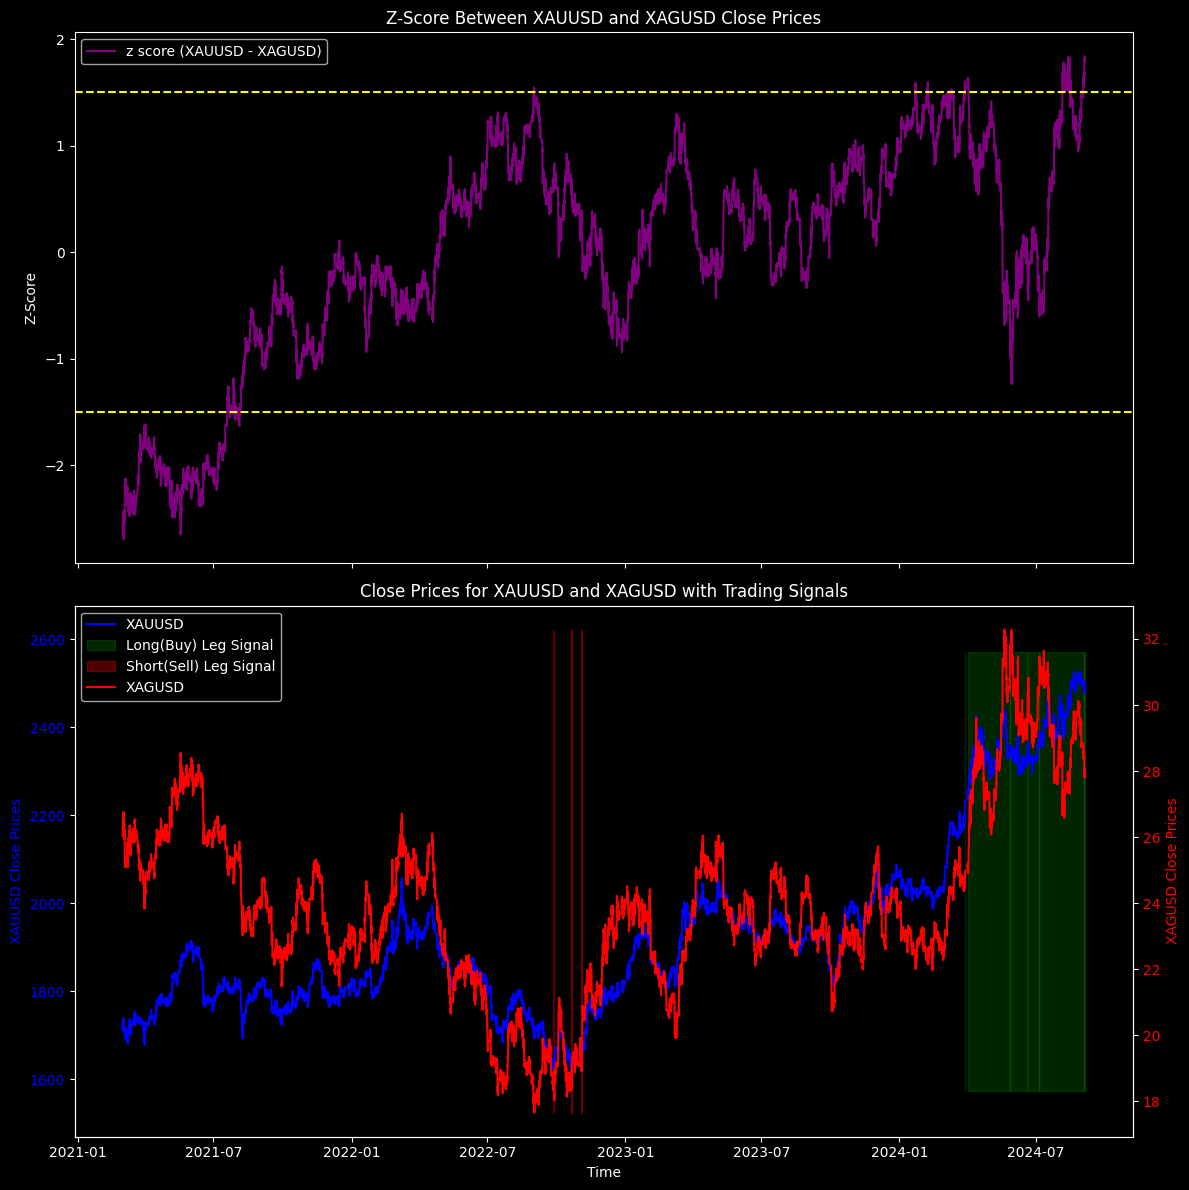

Number of signals != 0: 1353
Fail to reject the null hypothesis. The XAUUSD/XAGUSD series is not stationary.
Cointegration: ❌


In [56]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)

# Z-score plot (top)
ax1.plot(z_scores.index, z_scores.values, label=f'z score ({symbolparam1} - {symbolparam2})', color='purple')
ax1.axhline(y=1.5, color='yellow', linestyle='--')
ax1.axhline(y=-1.5, color='yellow', linestyle='--')
ax1.set_ylabel('Z-Score')
ax1.set_title(f'Z-Score Between {symbolparam1} and {symbolparam2} Close Prices')
ax1.legend()

# Close prices and signals plot (bottom)
ax2.plot(trading_data.index, trading_data[symbolparam1], label=symbolparam1, color='blue')
ax2.set_ylabel(f'{symbolparam1} Close Prices', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax2_twin = ax2.twinx()
ax2_twin.plot(trading_data.index, trading_data[symbolparam2], label=symbolparam2, color='red')
ax2_twin.set_ylabel(f'{symbolparam2} Close Prices', color='red')
ax2_twin.tick_params(axis='y', labelcolor='red')

# Plot signals with reduced opacity
ax2.fill_between(trading_data.index, ax2.get_ylim()[0], ax2.get_ylim()[1], 
                 where=(trading_data['Signal'] > 0), 
                 color='green', alpha=0.3, label='Long(Buy) Leg Signal')
ax2.fill_between(trading_data.index, ax2.get_ylim()[0], ax2.get_ylim()[1], 
                 where=(trading_data['Signal'] < 0), 
                 color='red', alpha=0.3, label='Short(Sell) Leg Signal')

ax2.set_title(f'Close Prices for {symbolparam1} and {symbolparam2} with Trading Signals')
ax2.set_xlabel('Time')

# Combine legends
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()
print(f'Number of signals != 0: {len(trading_data['Signal'][trading_data['Signal'] != 0])}')
# Interpret the results
if p_value < 0.05:
    print(f'Reject the null hypothesis. The {symbolparam1}/{symbolparam2} series is stationary.')
    print(f'Cointegration: ✅')
else:
    print(f'Fail to reject the null hypothesis. The {symbolparam1}/{symbolparam2} series is not stationary.') 
    print(f'Cointegration: ❌')
    


***COINTEGRATION FUNCTION***

In [57]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np

def check_cointegration(df, symbol1, symbol2, significance_level=0.05):
    """
    Check for cointegration between two symbols using the Augmented Dickey-Fuller test.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing close prices for both symbols
    symbol1 (str): Name of the first symbol
    symbol2 (str): Name of the second symbol
    significance_level (float): Significance level for the ADF test (default: 0.05)
    
    Returns:
    dict: A dictionary containing test results and interpretation
    """
    # Extract close prices
    price1 = df[symbol1]['close'].dropna()
    price2 = df[symbol2]['close'].dropna()
    
    # Normalize prices
    norm_price1 = (price1 - price1.mean()) / price1.std()
    norm_price2 = (price2 - price2.mean()) / price2.std()
    
    # Calculate price difference
    price_diff = norm_price1 - norm_price2
    
    # Perform Augmented Dickey-Fuller test
    result = adfuller(price_diff.dropna())
    
    # Extract test statistics and p-value
    adf_statistic = result[0]
    p_value = result[1]
    
    # Interpret the results
    is_cointegrated = p_value < significance_level
    interpretation = (
        f"Reject the null hypothesis. The {symbol1}/{symbol2} series is stationary."
        if is_cointegrated
        else f"Fail to reject the null hypothesis. The {symbol1}/{symbol2} series is not stationary."
    )
    
    return {
        'symbol1': symbol1,
        'symbol2': symbol2,
        'adf_statistic': adf_statistic,
        'p_value': p_value,
        'is_cointegrated': is_cointegrated,
        'interpretation': interpretation,
    }

# # ------------------------------ EXAMPLE USAGE ------------------------------
# result = check_cointegration(symbols_data_concatenated, 'XAUUSD', 'XAGUSD')
# print(f"ADF Statistic: {result['adf_statistic']}")
# print(f"p-value: {result['p_value']}")
# print(result['interpretation'])
# print(f"Cointegration: {result['cointegration_status']}")

***CONSTRUCTING THE SPREAD***

In [58]:
def construct_spread(df, symbol1, symbol2):
    spread = df[symbol1]['close'] - df[symbol2]['close']
    z_score = (spread - spread.mean()) / spread.std()
    return pd.DataFrame({
        'spread': spread,
        'z_score': z_score,
        'signal': z_score.apply(lambda z: 1 if z > 1.5 else (-1 if z < -1.5 else 0))
    })

# ------------------------------ EXAMPLE USAGE ------------------------------
spread_data = construct_spread(symbols_data_concatenated, symbolparam1, symbolparam2)

***PAIRS TRADING OBJECT***

In [59]:
import matplotlib.dates as mdates
from datetime import datetime, timedelta


class DynamicPairsTrading():
	def __init__(self, df, timeframe, symbol1, symbol2, window_days=30, entry_threshold=1.5, exit_threshold=0):
		self.df = df
		# Ensure the index is datetime
		self.df.index = pd.to_datetime(self.df.index)

		self.timeframe = timeframe

		self.symbol1 = symbol1
		self.symbol2 = symbol2
		symbol1_close = df[self.symbol1]['close']
		symbol2_close = df[self.symbol2]['close']

		# Normalise prices
		norm_symbol1 = (symbol1_close - symbol1_close.mean()) / symbol1_close.std()
		norm_symbol2 = (symbol2_close - symbol2_close.mean()) / symbol2_close.std()
		
		# Calculate spread using normalised prices
		self.spread = norm_symbol1 - norm_symbol2
		self.window_days = window_days
		self.entry_threshold = entry_threshold
		self.exit_threshold = exit_threshold
		# |----------------------------- SLIDING WINDOW EXPLANATION ------------------------------
		# | Calculate rolling mean and standard deviation usign a sliding window approach
		# | For each point in time the code considers the last window_days number of data points. 
		# | As new data points come in, the oldest data point in the window is dropped, and the new data point is added.
		# | By using a sliding window the strategy can detect the spread in recent behaviour rather than its behaviour over the entire dataset
		# | WINDOW SIZE IMPORTANCE:
		# | 	The window_days parameter determines how many recetn data points are considered.
		# | 	A SMALLER window_days makes the strategy more responsive to recent canges but potentially more prone to false signals.
		# | 	A LARGER window_days makes the strategy more stable but slower to react to canges in the relationship between pairs.

		self.end_time = datetime.now()
		self.start_time = datetime.now() - timedelta(days=self.window_days)
		self.rolling_mean = self.spread.mean()
		self.rolling_std = self.spread.std()

		self.z_score = pd.Series(index=self.df.index)

		# Calculate rolling z-score
		self.calculate_rolling_zscore()

		# ------------------------------ SIGNALS STORAGE ------------------------------
		self.signals = pd.Series(index=self.z_score.index, dtype=int)
		self.exits = pd.Series(index=self.z_score.index, dtype=bool)
		# The position variable keeps track of the current trading position:
		# 0 means no position
		# 1 means a long position (buying the spread)
		# -1 means a short position (selling the spread)
		self.position = 0


	def get_data(self, symbol, timeframe, start_date, end_time):
		rates = mt5.copy_rates_range(symbol, timeframe, start_date, end_time)
		df = pd.DataFrame(rates)
		df = df[['time','close']]
		df['time'] = pd.to_datetime(df['time'], unit='s')
		df.set_index('time', inplace=True)
		return df
	

	def normalise_series(self, series):
		return (series - series.mean()) / series.std()

	
	def calculate_rolling_zscore(self):
		self.z_score = pd.Series(index=self.df.index)
		# window = datetime.now() - timedelta(days=self.window_days)
		window = end_time - timedelta(days=self.window_days)

		symbol1_window_df = get_data(self.symbol1, self.timeframe, window, self.df.index[-1])
		symbol2_window_df = get_data(self.symbol2, self.timeframe, window, self.df.index[-1])
		# print('--------------------')
		# print(symbol1_window_df)
		# print('--------------------')
		# print(symbol2_window_df)
		
		# Ensure both dataframes have the same index
		common_index = symbol1_window_df.index.intersection(symbol2_window_df.index)
		symbol1_window_df = symbol1_window_df.loc[common_index]
		symbol2_window_df = symbol2_window_df.loc[common_index]
		# print('--------------------')
		# print(symbol2_window_df)
		# print('--------------------')
		# print(symbol2_window_df)
		
		# Calculate the spread for the window
		norm_symbol1 = (symbol1_window_df['close'] - symbol1_window_df['close'].mean()) / symbol1_window_df['close'].std()
		norm_symbol2 = (symbol2_window_df['close'] - symbol2_window_df['close'].mean()) / symbol2_window_df['close'].std()
		window_spread = norm_symbol1 - norm_symbol2
		print('--------------------')
		print(window_spread)

		window_spread = window_spread.dropna()

		# Calculate mean and standard deviation
		mu = window_spread.mean()
		sigma = window_spread.std()

		# Calculate Z-score for each data point
		self.z_score = (window_spread - mu) / sigma
		
		# Forward fill any NaN values that might occur at the start
		# self.z_score = self.z_score.fillna(method='ffill')


	def construct_spread(self):
		spread = self.df[self.symbol1]['close'] - self.df[self.symbol2]['close']
		z_score = (spread - spread.mean()) / spread.std()
		return pd.DataFrame({
			'spread': spread,
			'z_score': z_score,
			'signal': z_score.apply(lambda z: 1 if z > self.entry_threshold else (-1 if z < -self.entry_threshold else 0))
		})


	def entry_exit_threshold_check(self):
		previous_z_score = 0
		open_trade = 0  # 0 for no trade, 1 for long, -1 for short
		exit_boundary = 0.2

		for i, current_z_score in enumerate(self.z_score):
			current_signal = 0
			current_exit = False

            # Check for exits first
			if open_trade != 0:  # if there are trades
				# print(f"previous_z_score: {previous_z_score}, current_z_score: {current_z_score}")
				# if (open_trade >= self.exit_threshold and previous_z_score >= self.exit_threshold >= current_z_score) or \
                #    (open_trade <= self.exit_threshold and previous_z_score <= self.exit_threshold <= current_z_score):
				# 	current_signal = 0
				# 	current_exit = True
				# 	open_trade = 0
				if (open_trade > 0 and previous_z_score >= exit_boundary > current_z_score) or \
				(open_trade < 0 and previous_z_score <= -exit_boundary < current_z_score):
					current_signal = 0
					current_exit = True
					open_trade = 0

            # Then check for entries if we don't have an open trade
			elif open_trade == 0:
				if previous_z_score <= self.entry_threshold < current_z_score:
					current_signal = -1  # Short the spread
					open_trade = -1
				elif previous_z_score >= -self.entry_threshold > current_z_score:
					current_signal = 1  # Long the spread
					open_trade = 1

            # Update signals and exits
			self.signals.iloc[i] = current_signal
			self.exits.iloc[i] = current_exit
			self.position = open_trade

			previous_z_score = current_z_score

		print(f"Final open trade: {open_trade}")

	
	def plot_strategy(self, save_dir='plots'):
		# Align indices
		common_index = self.df.index.intersection(self.exits.index)
		aligned_df = self.df.loc[common_index]
		aligned_exits = self.exits.loc[common_index]
		aligned_signals = self.signals.loc[common_index]
		aligned_z_score = self.z_score.loc[common_index]
		fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
		
		# Z-score plot (top)
		# ax1.plot(self.z_score.index, self.z_score, label='Dynamic Z-score', color='purple')
		ax1.plot(aligned_z_score.index, aligned_z_score, label='Dynamic Z-score', color='purple')
		ax1.axhline(y=self.entry_threshold, color='yellow', linestyle='--', label='Entry Threshold')
		ax1.axhline(y=-self.entry_threshold, color='yellow', linestyle='--')
		ax1.axhline(y=self.exit_threshold, color='green', linestyle='--', label='Exit Threshold')
		ax1.axhline(y=-self.exit_threshold, color='green', linestyle='--')
		
		# Add exit points to Z-score plot
		# exit_points = self.z_score[self.exits]
		exit_points = aligned_z_score[aligned_exits]
		ax1.scatter(exit_points.index, exit_points, color='white', marker='x', s=100, label='Exit Points')
		
		# Add entry points to Z-score plot
		# entry_points = self.z_score[self.signals != 0]
		entry_points = aligned_z_score[aligned_signals != 0]
		ax1.scatter(entry_points.index, entry_points, color='yellow', marker='.', s=100, label='Entry Points')
		
		ax1.set_ylabel('Z-Score')
		ax1.set_title(f'Dynamic Z-Score Between {self.symbol1} and {self.symbol2} Close Prices')
		ax1.legend()

		# Close prices and signals plot (bottom)
		# ax2.plot(self.df.index, self.df[self.symbol1]['close'], label=self.symbol1, color='blue')
		ax2.plot(aligned_df.index, aligned_df[self.symbol1]['close'], label=self.symbol1, color='blue')
		ax2.set_ylabel(f'{self.symbol1} Close Prices', color='blue')
		ax2.tick_params(axis='y', labelcolor='blue')

		ax2_twin = ax2.twinx()
		# ax2_twin.plot(self.df.index, self.df[self.symbol2]['close'], label=self.symbol2, color='red')
		ax2_twin.plot(aligned_df.index, aligned_df[self.symbol2]['close'], label=self.symbol2, color='red')
		ax2_twin.set_ylabel(f'{self.symbol2} Close Prices', color='red')
		ax2_twin.tick_params(axis='y', labelcolor='red')

		# Plot signals		
		ax2.fill_between(aligned_signals.index, ax2.get_ylim()[0], ax2.get_ylim()[1], 
                    where=(aligned_signals > 0), 
                    color='green', alpha=0.3, label='Long Signal')
		ax2.fill_between(aligned_signals.index, ax2.get_ylim()[0], ax2.get_ylim()[1], 
                    where=(aligned_signals < 0), 
                    color='red', alpha=0.3, label='Short Signal')

		# Plot exits on price chart
		# exit_points = self.df[self.exits][self.symbol1]['close']
		exit_points = aligned_df[aligned_exits][self.symbol1]['close']
		ax2.scatter(exit_points.index, exit_points, color='white', marker='x', s=100, label='Exit Points')

		# Plot entries on price chart
		# entry_points = self.df[self.signals != 0][self.symbol1]['close']
		entry_points = aligned_df[aligned_signals != 0][self.symbol1]['close']
		ax2.scatter(entry_points.index, entry_points, color='yellow', marker='.', s=100, label='Entry Points')

		ax2.set_title(f'Close Prices for {self.symbol1} and {self.symbol2} with Dynamic Trading Signals')
		ax2.set_xlabel('Time')

		# Combine legends
		lines1, labels1 = ax2.get_legend_handles_labels()
		lines2, labels2 = ax2_twin.get_legend_handles_labels()
		ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

		# Format x-axis to show dates nicely
		fig.autofmt_xdate()
		ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
		ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

		plt.tight_layout()

		# Save the plot
		os.makedirs(save_dir, exist_ok=True)
		filename = f"{self.symbol1}_{self.symbol2}_strategy.png"
		filepath = os.path.join(save_dir, filename)
		plt.savefig(filepath, dpi=300, bbox_inches='tight')
		plt.close(fig)

		print(f"Plot saved to: {filepath}")
		print(f'Number of signals != 0: {len(self.signals[self.signals != 0])}')
		print(f'Number of exits: {self.exits.sum()}')
			
	# ------------------------------ BACKTEST AND EVALUATION - ***CLAUDE AI*** ------------------------------
	def backtest(self):
		position = 0
		entry_price = 0
		trades = []
		
		# Iterate through the data
		for i in range(len(self.z_score)):
			if self.signals.iloc[i] != 0 and position == 0:
				# Enter a new position
				position = self.signals.iloc[i]
				entry_price = self.spread.iloc[i]
			elif self.exits.iloc[i] and position != 0:
				# Exit the position
				exit_price = self.spread.iloc[i]
				pnl = (exit_price - entry_price) * position
				trades.append({
					'entry_date': self.z_score.index[i - 1],
					'exit_date': self.z_score.index[i],
					'entry_price': entry_price,
					'exit_price': exit_price,
					'position': position,
					'pnl': pnl
				})
				position = 0
				entry_price = 0
		
		return pd.DataFrame(trades)
	

	def calculate_performance_metrics(self, trades_df):
		if trades_df.empty:
			return {
				'total_trades': 0,
				'winning_trades': 0,
				'losing_trades': 0,
				'win_rate': 0,
				'total_pnl': 0,
				'average_pnl_per_trade': 0,
				'sharpe_ratio': 0,
				'max_drawdown': 0
			}
		
		total_trades = len(trades_df)
		winning_trades = len(trades_df[trades_df['pnl'] > 0])
		losing_trades = len(trades_df[trades_df['pnl'] <= 0])
		win_rate = winning_trades / total_trades if total_trades > 0 else 0
		total_pnl = trades_df['pnl'].sum()
		average_pnl_per_trade = total_pnl / total_trades if total_trades > 0 else 0
		
		# Calculate Sharpe ratio
		returns = trades_df['pnl'] / trades_df['entry_price']
		sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252) if returns.std() != 0 else 0
		
		# Calculate max drawdown
		cumulative_returns = (1 + returns).cumprod()
		peak = cumulative_returns.expanding(min_periods=1).max()
		drawdown = (cumulative_returns / peak) - 1
		max_drawdown = drawdown.min()
		
		return {
			'total_trades': total_trades,
			'winning_trades': winning_trades,
			'losing_trades': losing_trades,
			'win_rate': win_rate,
			'total_pnl': total_pnl,
			'average_pnl_per_trade': average_pnl_per_trade,
			'sharpe_ratio': sharpe_ratio,
			'max_drawdown': max_drawdown
		}
	

	def run_backtest_and_analyze(self):
		# Run the backtest
		trades_df = self.backtest()
		
		# Calculate performance metrics
		metrics = self.calculate_performance_metrics(trades_df)
		
		# Print results
		print("Backtest Results:")
		print(f"Total Trades: {metrics['total_trades']}")
		print(f"Winning Trades: {metrics['winning_trades']}")
		print(f"Losing Trades: {metrics['losing_trades']}")
		print(f"Win Rate: {metrics['win_rate']:.2%}")
		print(f"Total PnL: {metrics['total_pnl']:.2f}")
		print(f"Average PnL per Trade: {metrics['average_pnl_per_trade']:.2f}")
		print(f"Sharpe Ratio: {metrics['sharpe_ratio']:.2f}")
		print(f"Max Drawdown: {metrics['max_drawdown']:.2%}")
		
		# Plot equity curve
		if not trades_df.empty:
			cumulative_pnl = trades_df['pnl'].cumsum()
			plt.figure(figsize=(12, 6))
			plt.plot(trades_df['exit_date'], cumulative_pnl)
			plt.title('Equity Curve')
			plt.xlabel('Date')
			plt.ylabel('Cumulative PnL')
			plt.grid(True)
			plt.show()
		
		return trades_df, metrics

--------------------
time
2021-12-09 12:00:00   -0.415063
2021-12-09 14:00:00   -0.313871
2021-12-09 16:00:00   -0.345368
2021-12-09 18:00:00   -0.354144
2021-12-09 20:00:00   -0.344101
                         ...   
2024-09-04 00:00:00    1.000790
2024-09-04 02:00:00    1.009438
2024-09-04 04:00:00    1.014403
2024-09-04 06:00:00    1.003615
2024-09-04 08:00:00    1.024599
Name: close, Length: 8438, dtype: float64
Final open trade: -1
Plot saved to: plots\XAUUSD_XAGUSD_strategy.png
Number of signals != 0: 8
Number of exits: 7
Backtest Results:
Total Trades: 7
Winning Trades: 6
Losing Trades: 1
Win Rate: 85.71%
Total PnL: 2.03
Average PnL per Trade: 0.29
Sharpe Ratio: -4.33
Max Drawdown: -102.21%


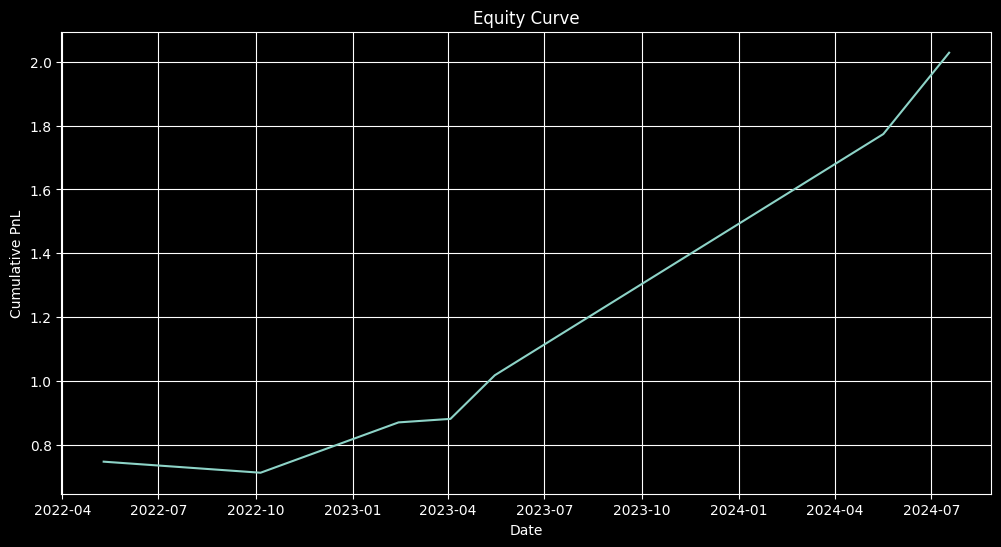

In [60]:
# |-----------------------------WINDOW SIZE AND TIMEFRAME EXPLANATION------------------------------
# | Window Size in Relation to Timeframe:
# | A 30-period window on daily data covers a month, while on 5-minute data it covers only 2.5 hours. 
# | This dramatically changes the strategy's perspective.

# | The window size should be large enough to capture relevant market cycles or seasonalities for the given timeframe.
# | Smaller window sizes relative to the timeframe make the strategy more sensitive to recent price movements.

# | Short Timeframe + Small Window = Very reactive strategy, potental false signals, good for capturing quick mean reversions.
# | Short Timeframe + Large Window = More stable signals on a short-term basis, may be slower to react to market context.
# | Long Timeframe + Small Window = Inconsistent as it might not capture enough market context.
# | Long Timeframe + Large Window = Stable long-term oriented strategy, fewer but more reliable signals

timeframe = mt5.TIMEFRAME_H2
pairs_trading = DynamicPairsTrading(symbols_data_concatenated, timeframe, 'XAUUSD', 'XAGUSD', window_days=1000, entry_threshold=1.35)
pairs_trading.entry_exit_threshold_check()
pairs_trading.plot_strategy()

# Run the backtest and analyze results
trades_df, metrics = pairs_trading.run_backtest_and_analyze()